# Assignment 4 – Ray Tune + Optuna | English → Hindi Transformer
**Roll No:** M25CSA011 | **Server:** 8x GTX 1080 Ti | **8 trials in parallel**

**Baseline:** 100 epochs | Loss=0.0972 | BLEU=68.02 | Time=129.42 min

In [1]:
# ── CELL 1: Install ───────────────────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'ray[tune]', 'optuna', '-q'], check=True)
print('Done.')

Done.


In [2]:
# ── CELL 2: Imports ───────────────────────────────────────────────────────────
import os, math, time, pickle, json, warnings
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import nltk
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
import ray
from ray import tune
from ray.tune.search.optuna import OptunaSearch
from ray.tune.schedulers import ASHAScheduler

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)

NUM_GPUS = torch.cuda.device_count()
print(f'Total GPUs found: {NUM_GPUS}')
for i in range(NUM_GPUS):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Total GPUs found: 8
  GPU 0: NVIDIA GeForce GTX 1080 Ti
  GPU 1: NVIDIA GeForce GTX 1080 Ti
  GPU 2: NVIDIA GeForce GTX 1080 Ti
  GPU 3: NVIDIA GeForce GTX 1080 Ti
  GPU 4: NVIDIA GeForce GTX 1080 Ti
  GPU 5: NVIDIA GeForce GTX 1080 Ti
  GPU 6: NVIDIA GeForce GTX 1080 Ti
  GPU 7: NVIDIA GeForce GTX 1080 Ti


In [4]:
# ── CELL 3: Load data ─────────────────────────────────────────────────────────
# Put English-Hindi.tsv in the same folder as this notebook
DATA_PATH = 'English-Hindi.tsv'

df = pd.read_csv(DATA_PATH, sep='\t', header=None, names=['id1','en','id2','hi'])
df = df[['en','hi']].dropna().reset_index(drop=True)
print(f'Total pairs: {len(df)}')
df.head()

Total pairs: 13186


,en,hi
0,Muiriel is 20 now.,म्यूरियल अब बीस साल की हो गई है।
1,Muiriel is 20 now.,म्यूरियल अब बीस साल की है।
2,Education in this world disappoints me.,मैं इस दुनिया में शिक्षा पर बहुत निराश हूँ।
3,That won't happen.,वैसा नहीं होगा।
4,I miss you.,मुझें तुम्हारी याद आ रही है।


In [5]:
# ── CELL 4: Vocabulary ────────────────────────────────────────────────────────
class Vocabulary:
    def __init__(self, freq_threshold=2):
        self.itos = {0:'<pad>',1:'<sos>',2:'<eos>',3:'<unk>'}
        self.stoi = {'<pad>':0,'<sos>':1,'<eos>':2,'<unk>':3}
        self.idx  = 4
        self.thr  = freq_threshold

    def build_vocab(self, sents):
        freq = Counter(w for s in sents for w in s.lower().strip().split())
        for w, c in freq.items():
            if c >= self.thr:
                self.stoi[w] = self.idx
                self.itos[self.idx] = w
                self.idx += 1

    def numericalize(self, s):
        return [self.stoi.get(w, 3) for w in s.lower().strip().split()]

    def __len__(self):       return len(self.stoi)
    def __getitem__(self,t): return self.stoi.get(t, 3)


en_vocab = Vocabulary(freq_threshold=2)
hi_vocab = Vocabulary(freq_threshold=2)
en_vocab.build_vocab(df['en'].tolist())
hi_vocab.build_vocab(df['hi'].tolist())

EN_VOCAB_SIZE = len(en_vocab)
HI_VOCAB_SIZE = len(hi_vocab)
SRC_PAD_IDX   = en_vocab['<pad>']
TGT_PAD_IDX   = hi_vocab['<pad>']
MAX_LEN       = 50
DEVICE        = torch.device('cuda:0')

print(f'EN vocab: {EN_VOCAB_SIZE} | HI vocab: {HI_VOCAB_SIZE}')
print(f'Main device: {DEVICE}')

EN vocab: 4117 | HI vocab: 4044
Main device: cuda:0


In [6]:
# ── CELL 5: Encoding helper ───────────────────────────────────────────────────
def encode_sentence(sentence, vocab, max_len=50):
    t = [vocab.stoi['<sos>']] + vocab.numericalize(sentence)[:max_len-2] + [vocab.stoi['<eos>']]
    return t + [vocab.stoi['<pad>']] * (max_len - len(t))

In [7]:
# ── CELL 6: Transformer model ─────────────────────────────────────────────────
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.h=num_heads; self.dk=d_model//num_heads; self.d=d_model
        self.Wq=nn.Linear(d_model,d_model); self.Wk=nn.Linear(d_model,d_model)
        self.Wv=nn.Linear(d_model,d_model); self.Wo=nn.Linear(d_model,d_model)
        self.drop=nn.Dropout(dropout)
    def forward(self, q, k, v, mask=None):
        B=q.size(0)
        Q=self.Wq(q).view(B,-1,self.h,self.dk).transpose(1,2)
        K=self.Wk(k).view(B,-1,self.h,self.dk).transpose(1,2)
        V=self.Wv(v).view(B,-1,self.h,self.dk).transpose(1,2)
        sc=torch.matmul(Q,K.transpose(-2,-1))/self.dk**0.5
        if mask is not None: sc=sc.masked_fill(mask==0,-1e9)
        o=torch.matmul(self.drop(torch.softmax(sc,dim=-1)),V)
        return self.Wo(o.transpose(1,2).contiguous().view(B,-1,self.d))

class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net=nn.Sequential(nn.Linear(d_model,d_ff),nn.ReLU(),nn.Dropout(dropout),nn.Linear(d_ff,d_model))
    def forward(self, x): return self.net(x)

class LayerNorm(nn.Module):
    def __init__(self, d_model, eps=1e-6):
        super().__init__()
        self.g=nn.Parameter(torch.ones(d_model)); self.b=nn.Parameter(torch.zeros(d_model)); self.eps=eps
    def forward(self, x):
        m=x.mean(-1,keepdim=True); s=x.std(-1,keepdim=True)
        return self.g*(x-m)/(s+self.eps)+self.b

class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.attn=MultiHeadAttention(d_model,num_heads,dropout)
        self.ffn=FeedForward(d_model,d_ff,dropout)
        self.n1=LayerNorm(d_model); self.n2=LayerNorm(d_model); self.drop=nn.Dropout(dropout)
    def forward(self, x, mask=None):
        x=self.n1(x+self.drop(self.attn(x,x,x,mask)))
        return self.n2(x+self.drop(self.ffn(x)))

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.sa=MultiHeadAttention(d_model,num_heads,dropout)
        self.ca=MultiHeadAttention(d_model,num_heads,dropout)
        self.ffn=FeedForward(d_model,d_ff,dropout)
        self.n1=LayerNorm(d_model); self.n2=LayerNorm(d_model); self.n3=LayerNorm(d_model)
        self.drop=nn.Dropout(dropout)
    def forward(self, x, enc, sm=None, tm=None):
        x=self.n1(x+self.drop(self.sa(x,x,x,tm)))
        x=self.n2(x+self.drop(self.ca(x,enc,enc,sm)))
        return self.n3(x+self.drop(self.ffn(x)))

class Transformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model=512, num_layers=6,
                 num_heads=8, d_ff=2048, max_len=50, dropout=0.1):
        super().__init__()
        self.enc_emb=nn.Embedding(src_vocab,d_model)
        self.dec_emb=nn.Embedding(tgt_vocab,d_model)
        self.pos=PositionalEncoding(d_model,max_len+10)
        self.enc_layers=nn.ModuleList([EncoderLayer(d_model,num_heads,d_ff,dropout) for _ in range(num_layers)])
        self.dec_layers=nn.ModuleList([DecoderLayer(d_model,num_heads,d_ff,dropout) for _ in range(num_layers)])
        self.fc_out=nn.Linear(d_model,tgt_vocab)
        self.drop=nn.Dropout(dropout)
    def pad_mask(self,seq,pad_idx): return (seq!=pad_idx).unsqueeze(1).unsqueeze(2)
    def sub_mask(self,sz,device): return torch.tril(torch.ones(sz,sz,device=device)).bool()
    def forward(self,src,tgt,src_pad,tgt_pad):
        dev=src.device
        sm=self.pad_mask(src,src_pad)
        tm=self.pad_mask(tgt,tgt_pad)&self.sub_mask(tgt.size(1),dev)
        x=self.drop(self.pos(self.enc_emb(src)))
        for l in self.enc_layers: x=l(x,sm)
        y=self.drop(self.pos(self.dec_emb(tgt)))
        for l in self.dec_layers: y=l(y,x,sm,tm)
        return self.fc_out(y)

print('Transformer defined.')

Transformer defined.


In [8]:
# ── CELL 7: Dataset & DataLoader ─────────────────────────────────────────────
class TranslationDataset(Dataset):
    def __init__(self, en_sents, hi_sents, en_vocab, hi_vocab, max_len=50):
        self.en=en_sents; self.hi=hi_sents
        self.ev=en_vocab; self.hv=hi_vocab; self.ml=max_len
    def __len__(self): return len(self.en)
    def __getitem__(self, i):
        return (torch.tensor(encode_sentence(self.en[i],self.ev,self.ml)),
                torch.tensor(encode_sentence(self.hi[i],self.hv,self.ml)))

def collate_fn(batch):
    src,tgt=zip(*batch)
    src=torch.stack(src); tgt=torch.stack(tgt)
    return src, tgt[:,:-1], tgt[:,1:]

print('Dataset defined.')

Dataset defined.


In [9]:
# ── CELL 8: BLEU helpers ──────────────────────────────────────────────────────
smoothie = SmoothingFunction().method4

val_dataset = [
    ('I love you.',                 'मैं तुमसे प्यार करता हूँ।'),
    ('How are you?',                'आप कैसे हैं?'),
    ('You should sleep.',           'आपको सोना चाहिए।'),
    ("Maybe Tom doesn't love you.", 'टॉम शायद तुमसे प्यार नहीं करता है।'),
    ('Let me tell Tom.',            'मुझे टॉम को बताने दीजिए।')
]

def translate_sentence(model, sentence, ev, hv, device, max_len=50):
    model.eval()
    src=torch.tensor(encode_sentence(sentence,ev,max_len)).unsqueeze(0).to(device)
    out=[hv['<sos>']]
    for _ in range(max_len):
        tgt=torch.tensor(out).unsqueeze(0).to(device)
        with torch.no_grad():
            logits=model(src,tgt,SRC_PAD_IDX,TGT_PAD_IDX)
        nxt=logits[0,-1].argmax().item()
        out.append(nxt)
        if nxt==hv['<eos>']: break
    return ' '.join([hv.itos[i] for i in out[1:-1]])

def evaluate_bleu(model, data, ev, hv, device):
    refs,hyps=[],[]
    for en_s,hi_s in data:
        pred=translate_sentence(model,en_s,ev,hv,device)
        refs.append([hi_s.split()]); hyps.append(pred.split())
    return corpus_bleu(refs,hyps,smoothing_function=smoothie)

print('BLEU helpers defined.')

BLEU helpers defined.


In [13]:
# KEY FIXES:
# 1. Uses tune.report() NOT ray.train.report()
# 2. Loads data from absolute path inside worker
# 3. All classes defined inside function (no pickling issues)

def train_tune(config):
    import os, math, torch
    import torch.nn as nn
    import torch.optim as optim
    import pandas as pd
    from collections import Counter
    from torch.utils.data import Dataset, DataLoader
    from ray import tune   # <-- tune.report() is correct for Ray Tune

    DATA_PATH = '/DATA/anikde/mahek/mlops_3/English-Hindi.tsv'

    class V:
        def __init__(self):
            self.itos={0:'<pad>',1:'<sos>',2:'<eos>',3:'<unk>'}
            self.stoi={'<pad>':0,'<sos>':1,'<eos>':2,'<unk>':3}
            self.idx=4
        def build(self,sents):
            from collections import Counter
            freq=Counter(w for s in sents for w in s.lower().strip().split())
            for w,c in freq.items():
                if c>=2:
                    self.stoi[w]=self.idx
                    self.itos[self.idx]=w
                    self.idx+=1
        def enc(self,s,ml=50):
            t=[1]+[self.stoi.get(w,3) for w in s.lower().strip().split()][:ml-2]+[2]
            return t+[0]*(ml-len(t))
        def __len__(self): return len(self.stoi)

    _df=pd.read_csv(DATA_PATH,sep='\t',header=None,names=['i1','en','i2','hi'])
    _df=_df[['en','hi']].dropna().reset_index(drop=True)
    ev=V(); hv=V()
    ev.build(_df['en'].tolist())
    hv.build(_df['hi'].tolist())

    class DS(Dataset):
        def __len__(self): return len(_df)
        def __getitem__(self,i):
            return torch.tensor(ev.enc(_df.en[i])), torch.tensor(hv.enc(_df.hi[i]))

    def col(b):
        s,t=zip(*b); s=torch.stack(s); t=torch.stack(t)
        return s,t[:,:-1],t[:,1:]

    loader=DataLoader(DS(),batch_size=config['batch_size'],
                      shuffle=True,collate_fn=col,num_workers=0)

    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    D=512; NL=6; ML=50
    H=config['num_heads']; DFF=config['d_ff']; DR=config['dropout']

    class PE(nn.Module):
        def __init__(self,d,ml=512):
            super().__init__()
            pe=torch.zeros(ml,d)
            pos=torch.arange(0,ml).unsqueeze(1).float()
            dv=torch.exp(torch.arange(0,d,2).float()*(-math.log(10000)/d))
            pe[:,0::2]=torch.sin(pos*dv); pe[:,1::2]=torch.cos(pos*dv)
            self.register_buffer('pe',pe.unsqueeze(0))
        def forward(self,x): return x+self.pe[:,:x.size(1)]

    class MHA(nn.Module):
        def __init__(self,d,h,dr):
            super().__init__()
            self.h=h; self.dk=d//h; self.d=d
            self.Wq=nn.Linear(d,d); self.Wk=nn.Linear(d,d)
            self.Wv=nn.Linear(d,d); self.Wo=nn.Linear(d,d)
            self.dr=nn.Dropout(dr)
        def forward(self,q,k,v,m=None):
            B=q.size(0)
            Q=self.Wq(q).view(B,-1,self.h,self.dk).transpose(1,2)
            K=self.Wk(k).view(B,-1,self.h,self.dk).transpose(1,2)
            V=self.Wv(v).view(B,-1,self.h,self.dk).transpose(1,2)
            sc=torch.matmul(Q,K.transpose(-2,-1))/self.dk**0.5
            if m is not None: sc=sc.masked_fill(m==0,-1e9)
            o=torch.matmul(self.dr(torch.softmax(sc,-1)),V)
            return self.Wo(o.transpose(1,2).contiguous().view(B,-1,self.d))

    class FF(nn.Module):
        def __init__(self,d,dff,dr):
            super().__init__()
            self.n=nn.Sequential(nn.Linear(d,dff),nn.ReLU(),
                                 nn.Dropout(dr),nn.Linear(dff,d))
        def forward(self,x): return self.n(x)

    class LN(nn.Module):
        def __init__(self,d):
            super().__init__()
            self.g=nn.Parameter(torch.ones(d))
            self.b=nn.Parameter(torch.zeros(d))
        def forward(self,x):
            m=x.mean(-1,keepdim=True); s=x.std(-1,keepdim=True)
            return self.g*(x-m)/(s+1e-6)+self.b

    class EL(nn.Module):
        def __init__(self,d,h,dff,dr):
            super().__init__()
            self.a=MHA(d,h,dr); self.f=FF(d,dff,dr)
            self.n1=LN(d); self.n2=LN(d); self.dr=nn.Dropout(dr)
        def forward(self,x,m=None):
            x=self.n1(x+self.dr(self.a(x,x,x,m)))
            return self.n2(x+self.dr(self.f(x)))

    class DL(nn.Module):
        def __init__(self,d,h,dff,dr):
            super().__init__()
            self.sa=MHA(d,h,dr); self.ca=MHA(d,h,dr); self.f=FF(d,dff,dr)
            self.n1=LN(d); self.n2=LN(d); self.n3=LN(d); self.dr=nn.Dropout(dr)
        def forward(self,x,e,sm=None,tm=None):
            x=self.n1(x+self.dr(self.sa(x,x,x,tm)))
            x=self.n2(x+self.dr(self.ca(x,e,e,sm)))
            return self.n3(x+self.dr(self.f(x)))

    class TF(nn.Module):
        def __init__(self,sv,tv,d,nl,h,dff,ml,dr):
            super().__init__()
            self.ee=nn.Embedding(sv,d); self.de=nn.Embedding(tv,d)
            self.pe=PE(d,ml+10)
            self.enc=nn.ModuleList([EL(d,h,dff,dr) for _ in range(nl)])
            self.dec=nn.ModuleList([DL(d,h,dff,dr) for _ in range(nl)])
            self.fc=nn.Linear(d,tv); self.dr=nn.Dropout(dr)
        def pm(self,s,p): return (s!=p).unsqueeze(1).unsqueeze(2)
        def sm(self,sz,dev): return torch.tril(torch.ones(sz,sz,device=dev)).bool()
        def forward(self,src,tgt,sp,tp):
            dev=src.device
            sm=self.pm(src,sp)
            tm=self.pm(tgt,tp)&self.sm(tgt.size(1),dev)
            x=self.dr(self.pe(self.ee(src)))
            for l in self.enc: x=l(x,sm)
            y=self.dr(self.pe(self.de(tgt)))
            for l in self.dec: y=l(y,x,sm,tm)
            return self.fc(y)

    model=TF(len(ev),len(hv),D,NL,H,DFF,ML,DR).to(device)
    opt=optim.AdamW(model.parameters(),
                    lr=config['lr'],
                    weight_decay=config['weight_decay'])
    sch=optim.lr_scheduler.CosineAnnealingLR(opt,
                    T_max=config['num_epochs'],eta_min=1e-6)
    crit=nn.CrossEntropyLoss(ignore_index=0)

    for epoch in range(config['num_epochs']):
        model.train(); total=0.0
        for src,ti,to in loader:
            src,ti,to=src.to(device),ti.to(device),to.to(device)
            out=model(src,ti,0,0)
            loss=crit(out.view(-1,out.size(-1)),to.view(-1))
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); total+=loss.item()
        sch.step()
        # ✅ CORRECT: tune.report() for Ray Tune
        tune.report({'loss': total/len(loader), 'epoch': epoch+1})

print('train_tune() defined.')

train_tune() defined.


In [14]:
# ── CELL 10: Search space ─────────────────────────────────────────────────────
search_space = {
    'lr':           tune.loguniform(1e-5, 1e-3),   # HP1
    'batch_size':   tune.choice([32, 64, 128]),     # HP2
    'num_heads':    tune.choice([4, 8]),            # HP3
    'd_ff':         tune.choice([1024, 2048, 4096]),# HP4
    'dropout':      tune.uniform(0.05, 0.40),       # HP5
    'weight_decay': tune.loguniform(1e-6, 1e-3),   # HP6
    'num_epochs':   30,
}
print('Search space defined.')

Search space defined.


In [28]:
# ── CELL 11: Run sweep (7 free GPUs in parallel) ─────────────────────────────
if ray.is_initialized():
    ray.shutdown()

# ✅ Use only GPUs 1-7 (GPU 0 is already occupied)
os.environ["CUDA_VISIBLE_DEVICES"] = "1,2,3,4,5,6,7"
FREE_GPUS = 7

ray.init(
    ignore_reinit_error=True,
    log_to_driver=False,
    num_gpus=FREE_GPUS
)

print(f'Ray initialized. Using GPUs: 1,2,3,4,5,6,7')
print(f'Trials in parallel: {FREE_GPUS}')

optuna_search  = OptunaSearch(metric='loss', mode='min')
asha_scheduler = ASHAScheduler(
    metric='loss', mode='min',
    max_t=30, grace_period=5, reduction_factor=3
)

tuner = tune.Tuner(
    tune.with_resources(train_tune, resources={'gpu': 1}),
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,
        scheduler=asha_scheduler,
        num_samples=20,
    ),
    param_space=search_space,
    run_config=tune.RunConfig(name='M25CSA011_sweep')
)

print('='*55)
print(f'  SWEEP: 20 trials, {FREE_GPUS} parallel, 1 GPU each')
print('  Expected time: ~5-10 minutes')
print('='*55)

sweep_start = time.time()
results     = tuner.fit()
sweep_time  = time.time() - sweep_start

print(f'\nSweep done in {sweep_time/60:.2f} minutes')

[2026-03-16 18:51:23,172 E 46893 44073] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
2026-03-16 19:40:52,045	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/DATA/anikde/ray_results/M25CSA011_sweep' in 0.0148s.
2026-03-16 19:40:52,068	INFO tune.py:1041 -- Total run time: 2998.89 seconds (2998.83 seconds for the tuning loop).



Sweep done in 49.98 minutes


In [29]:
# ── CELL 12: Best config ──────────────────────────────────────────────────────
best_result = results.get_best_result(metric='loss', mode='min')
best_config = best_result.config
best_loss   = best_result.metrics['loss']
best_epoch  = best_result.metrics['epoch']

print('='*52)
print('  BEST CONFIG – RAY TUNE + OPTUNA')
print('='*52)
for k, v in best_config.items():
    if k == 'num_epochs': continue
    print(f'  {k:<20}: {v}')
print(f'\n  Best Loss  : {best_loss:.4f}')
print(f'  Best Epoch : {best_epoch}')
print('='*52)

df_res = results.get_dataframe()
cols = ['loss','epoch','config/lr','config/batch_size',
        'config/num_heads','config/d_ff','config/dropout','config/weight_decay']
cols = [c for c in cols if c in df_res.columns]
print('\nAll 20 trials sorted by loss:')
print(df_res[cols].sort_values('loss').to_string(index=False))

  BEST CONFIG – RAY TUNE + OPTUNA
  lr                  : 0.00010092277088632719
  batch_size          : 64
  num_heads           : 4
  d_ff                : 4096
  dropout             : 0.05440091406982377
  weight_decay        : 0.0002615454502348676

  Best Loss  : 0.0957
  Best Epoch : 30

All 20 trials sorted by loss:
    loss  epoch  config/lr  config/batch_size  config/num_heads  config/d_ff  config/dropout  config/weight_decay
0.095704     30   0.000101                 64                 4         4096        0.054401             0.000262
0.125871     30   0.000168                128                 4         1024        0.051070             0.000013
0.131339     30   0.000277                 32                 8         2048        0.161801             0.000014
0.900534     30   0.000091                128                 4         1024        0.068978             0.000057
0.906778     30   0.000093                128                 4         1024        0.073987             

In [30]:
# ── CELL 13: Retrain best model (30 epochs on GPU 0) ─────────────────────────
RETRAIN_EPOCHS = 30

best_model = Transformer(
    src_vocab=EN_VOCAB_SIZE, tgt_vocab=HI_VOCAB_SIZE,
    d_model=512, num_layers=6,
    num_heads=best_config['num_heads'],
    d_ff=best_config['d_ff'],
    max_len=MAX_LEN,
    dropout=best_config['dropout']
).to(DEVICE)

optimizer = optim.AdamW(best_model.parameters(),
                        lr=best_config['lr'],
                        weight_decay=best_config['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=RETRAIN_EPOCHS, eta_min=1e-6)
criterion = nn.CrossEntropyLoss(ignore_index=TGT_PAD_IDX)

train_loader = DataLoader(
    TranslationDataset(df['en'].tolist(), df['hi'].tolist(),
                       en_vocab, hi_vocab, MAX_LEN),
    batch_size=best_config['batch_size'],
    shuffle=True, collate_fn=collate_fn, num_workers=4
)

loss_history  = []
retrain_start = time.time()

for epoch in range(RETRAIN_EPOCHS):
    best_model.train(); total=0.0
    for src,ti,to in train_loader:
        src,ti,to=src.to(DEVICE),ti.to(DEVICE),to.to(DEVICE)
        out=best_model(src,ti,SRC_PAD_IDX,TGT_PAD_IDX)
        loss=criterion(out.view(-1,out.size(-1)),to.view(-1))
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(best_model.parameters(),1.0)
        optimizer.step(); total+=loss.item()
    scheduler.step()
    avg=total/len(train_loader)
    loss_history.append(avg)
    print(f'Epoch [{epoch+1:>3}/{RETRAIN_EPOCHS}]  loss={avg:.4f}')

retrain_time = time.time() - retrain_start
total_time   = sweep_time + retrain_time

print(f'\nSweep time   : {sweep_time/60:.2f} min')
print(f'Retrain time : {retrain_time/60:.2f} min')
print(f'Total time   : {total_time/60:.2f} min')
print(f'Final loss   : {loss_history[-1]:.4f}')

Epoch [  1/30]  loss=5.1216
Epoch [  2/30]  loss=3.8804
Epoch [  3/30]  loss=3.2357
Epoch [  4/30]  loss=2.7452
Epoch [  5/30]  loss=2.3186
Epoch [  6/30]  loss=1.9638
Epoch [  7/30]  loss=1.6448
Epoch [  8/30]  loss=1.3660
Epoch [  9/30]  loss=1.1343
Epoch [ 10/30]  loss=0.9303
Epoch [ 11/30]  loss=0.7608
Epoch [ 12/30]  loss=0.6215
Epoch [ 13/30]  loss=0.5118
Epoch [ 14/30]  loss=0.4229
Epoch [ 15/30]  loss=0.3528
Epoch [ 16/30]  loss=0.2960
Epoch [ 17/30]  loss=0.2546
Epoch [ 18/30]  loss=0.2196
Epoch [ 19/30]  loss=0.1965
Epoch [ 20/30]  loss=0.1734
Epoch [ 21/30]  loss=0.1565
Epoch [ 22/30]  loss=0.1433
Epoch [ 23/30]  loss=0.1323
Epoch [ 24/30]  loss=0.1229
Epoch [ 25/30]  loss=0.1155
Epoch [ 26/30]  loss=0.1086
Epoch [ 27/30]  loss=0.1042
Epoch [ 28/30]  loss=0.1003
Epoch [ 29/30]  loss=0.0976
Epoch [ 30/30]  loss=0.0959

Sweep time   : 49.98 min
Retrain time : 29.33 min
Total time   : 79.31 min
Final loss   : 0.0959


In [31]:
# ── CELL 14: BLEU score ───────────────────────────────────────────────────────
bleu = evaluate_bleu(best_model, val_dataset, en_vocab, hi_vocab, DEVICE)
print(f'BLEU (tuned, {RETRAIN_EPOCHS} epochs) : {bleu*100:.2f}')
print(f'BLEU (baseline, 100 epochs)  : 68.02')
print(f'Difference                   : {(bleu*100 - 68.02):+.2f} pp')

print('\nSample translations:')
for s in ['I love you.','What is your name?','How are you?',
          'The weather is nice today.','She is a good teacher.']:
    t = translate_sentence(best_model, s, en_vocab, hi_vocab, DEVICE)
    print(f'  EN: {s}\n  HI: {t}\n')

BLEU (tuned, 30 epochs) : 90.38
BLEU (baseline, 100 epochs)  : 68.02
Difference                   : +22.36 pp

Sample translations:
  EN: I love you.
  HI: मैं तुमसे प्यार करता हूँ।

  EN: What is your name?
  HI: आपका नाम क्या है?

  EN: How are you?
  HI: आप कैसे हो?

  EN: The weather is nice today.
  HI: मौसम आज का मौसम है।

  EN: She is a good teacher.
  HI: वह एक अच्छी अध्यापिका है.



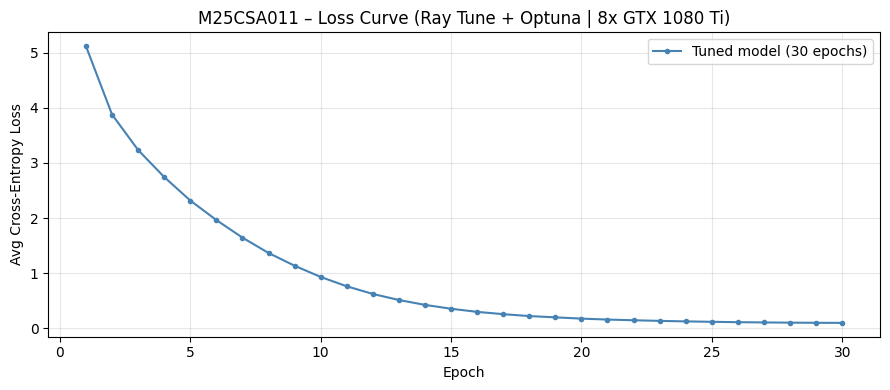

Saved: loss_curve_tuned.png


In [37]:
# — CELL 15: Loss curve
plt.figure(figsize=(9,4))

plt.plot(range(1, len(loss_history)+1), loss_history,
         marker='o', markersize=3, color='steelblue',
         linewidth=1.5, label='Tuned model (30 epochs)')

plt.xlabel('Epoch')
plt.ylabel('Avg Cross-Entropy Loss')
plt.title('M25CSA011 – Loss Curve (Ray Tune + Optuna | 8x GTX 1080 Ti)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('loss_curve_tuned.png', dpi=150)
plt.show()

print('Saved: loss_curve_tuned.png')

In [35]:
# ── CELL 16: Save model & vocab ───────────────────────────────────────────────
torch.save(best_model.state_dict(), 'M25CSA011_ass_4_best_model.pth')
print('Saved: M25CSA011_ass_4_best_model.pth')

with open('en_vocab.pkl','wb') as f: pickle.dump(en_vocab,f)
with open('hi_vocab.pkl','wb') as f: pickle.dump(hi_vocab,f)
print('Saved: en_vocab.pkl, hi_vocab.pkl')

with open('best_config.json','w') as f:
    json.dump({k:v for k,v in best_config.items() if k!='num_epochs'},f,indent=2)
print('Saved: best_config.json')

Saved: M25CSA011_ass_4_best_model.pth
Saved: en_vocab.pkl, hi_vocab.pkl
Saved: best_config.json


In [36]:
# ── CELL 17: Final summary ────────────────────────────────────────────────────
print('\n'+'='*62)
print('       M25CSA011 – ASSIGNMENT 4 RESULTS SUMMARY')
print('='*62)
print(f"{'Metric':<32} {'Baseline':>13} {'Tuned':>13}")
print('-'*62)
print(f"{'Epochs':<32} {'100':>13} {RETRAIN_EPOCHS:>13}")
print(f"{'Sweep Time (8 GPUs parallel)':<32} {'–':>13} {sweep_time/60:>12.2f}m")
print(f"{'Retrain Time (GPU 0)':<32} {'–':>13} {retrain_time/60:>12.2f}m")
print(f"{'Total Time':<32} {'129.42 min':>13} {total_time/60:>12.2f}m")
print(f"{'Final Loss':<32} {'0.0972':>13} {loss_history[-1]:>13.4f}")
print(f"{'BLEU Score (%)':<32} {'68.02':>13} {bleu*100:>13.2f}")
print('-'*62)
print(f"{'Speedup vs baseline':<32} {'–':>13} {129.42/(total_time/60):>12.1f}x")
print(f"{'Epoch reduction':<32} {'–':>13} {100-RETRAIN_EPOCHS:>12}ep")
print('='*62)
print('\nBest Hyperparameters:')
for k,v in best_config.items():
    if k=='num_epochs': continue
    print(f'  {k:<22}: {v}')


       M25CSA011 – ASSIGNMENT 4 RESULTS SUMMARY
Metric                                Baseline         Tuned
--------------------------------------------------------------
Epochs                                     100            30
Sweep Time (8 GPUs parallel)                 –        49.98m
Retrain Time (GPU 0)                         –        29.33m
Total Time                          129.42 min        79.31m
Final Loss                              0.0972        0.0959
BLEU Score (%)                           68.02         90.38
--------------------------------------------------------------
Speedup vs baseline                          –          1.6x
Epoch reduction                              –           70ep

Best Hyperparameters:
  lr                    : 0.00010092277088632719
  batch_size            : 64
  num_heads             : 4
  d_ff                  : 4096
  dropout               : 0.05440091406982377
  weight_decay          : 0.0002615454502348676
